In [22]:
import torch
import torchvision.models as models
import backbone.Test as test
import timm
import backbone.Custom as Custom
from torch.utils.data import Dataset, DataLoader
import backbone.VISUAL as viz
import backbone.GalaxyZoo as gz
import importlib
import backbone.AstroMLmodified as AstroMLmod

# Data

In [118]:
importlib.reload(gz)

train,val,class_  = gz.Galaxy_zoo_data_loaders(train_split = 0.3)

Saved :  Umap on UMAMP embedding.csv
UMAP reduced in  8.374054908752441


<Figure size 1050x787.5 with 0 Axes>

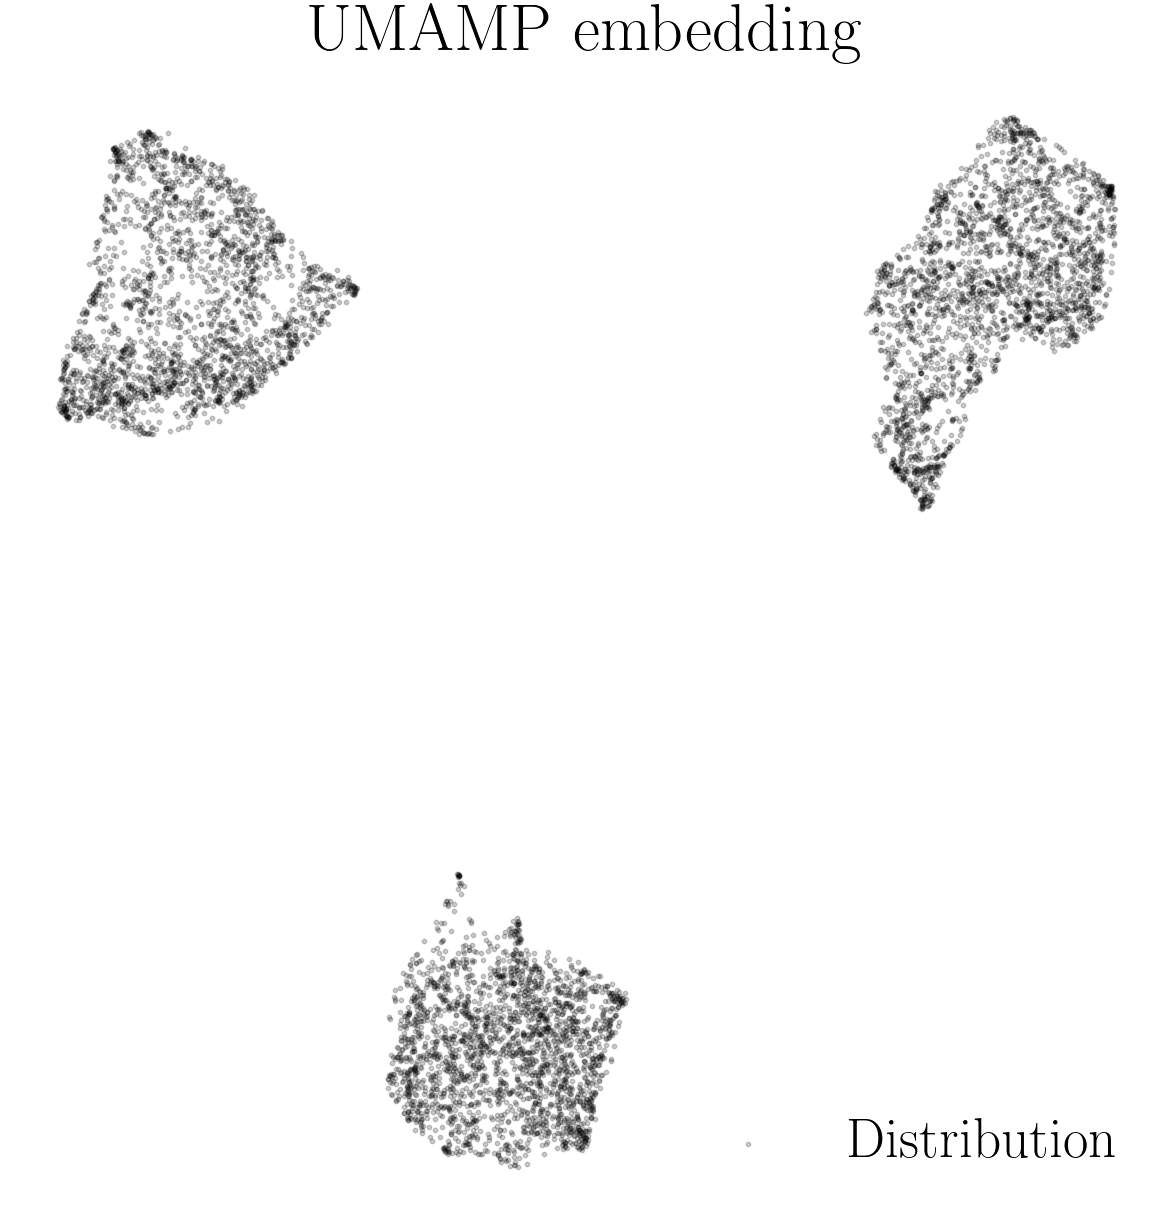

(98.24, 0.1)


ValueError: 'J154344.34+065955.1.png' is not in list

In [119]:
## Model: Zoobot ConvNext Base

zoobot_encoder = timm.create_model('hf_hub:mwalmsley/zoobot-encoder-convnext_base', pretrained=True, num_classes=0)


importlib.reload(Custom)
zoobot_rep, zoobot_label, zoobot_ids = Custom.get_representations(model  = zoobot_encoder,
                           loader = train,
                           encoder = True,
                           labeled = False)


zoobot_rep_c, zoobot_label_c, zoobot_ids_c = Custom.get_representations(model  = zoobot_encoder,
                           loader = class_,
                           encoder = True,
                           labeled = True)

umap_cs  =viz.umap(zoobot_rep_c)

knn = test.KNN_accuracy(zoobot_rep_c, zoobot_label_c)
print(knn)
c_accuracy = test.clustering_accuracy((zoobot_rep,zoobot_ids),(zoobot_label_c,zoobot_ids_c))
zoobot_tpcf = AstroMLmod.TPCF_score(zoobot_rep)
print(zoobot_tpcf)
zoobot_id = AstroMLmod.id_score(zoobot_rep)
print(zoobot_id)

## Model: Dino ConvNext base

Device:  cuda
Device:  cuda
Saved :  Umap on UMAMP embedding.csv
UMAP reduced in  8.05604887008667


<Figure size 1050x787.5 with 0 Axes>

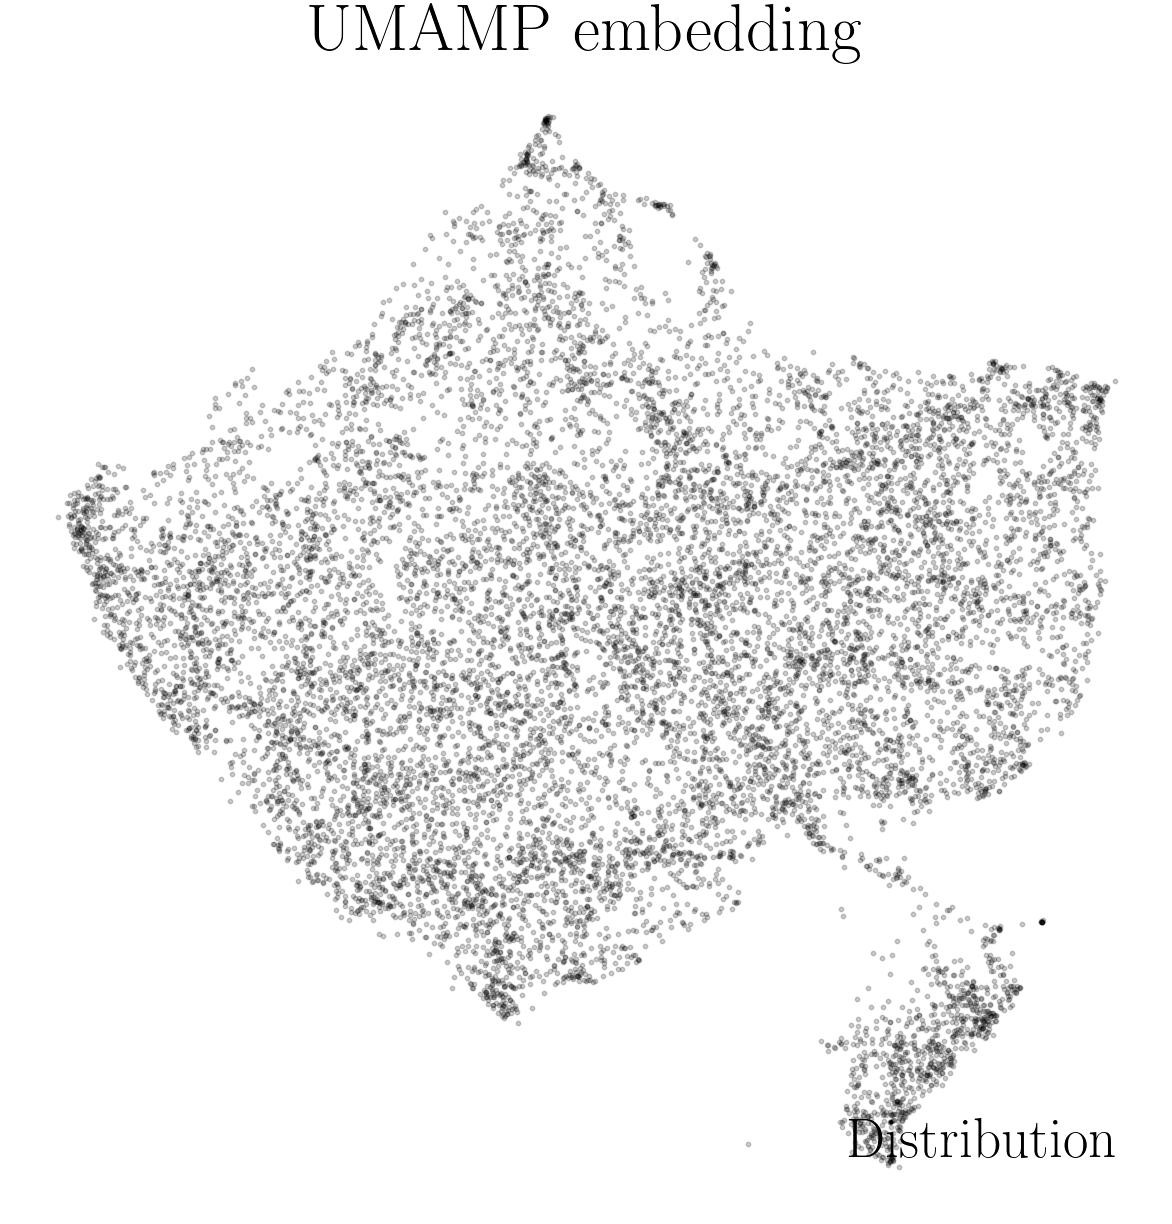

(93.95, 0.21)
Clustering accuracy 0.3495557074504443
Variance to keep :  0.4751083394646638  number of components :  2
51.11688008175864
0.4950546137990325
Computing background and RR distributions: will be slower
Background factor 1
Number of valid bins:  99
Repley's K:  (2.308883681230707, 0.00042801599266709714)
Variance to keep :  0.4928045165782769  number of components :  2
51.05676104514851
0.5015167718096875
Computing background and RR distributions: will be slower
Background factor 1
Number of valid bins:  99
Repley's K:  (2.2740181383569125, 0.00043388772655720263)
Variance to keep :  0.48204113061833753  number of components :  2
53.34145213616087
0.47259646569525554
Computing background and RR distributions: will be slower
Background factor 1
Number of valid bins:  99
Repley's K:  (2.2089654508335235, 0.0003866551283477887)
Variance to keep :  0.4879197092050118  number of components :  2
52.08727793437386
0.4905717856843199
Computing background and RR distributions: will b

In [10]:
dinov3_convnext_base = torch.hub.load("../dinov3", 'dinov3_convnext_base',
                                      source='local',
                                      weights="dinov3_convnext_base_pretrain_lvd1689m-801f2ba9.pth")
dino_rep, dino_label, dino_ids = Custom.get_representations(model  = dinov3_convnext_base,
                           loader = train,
                           encoder = True,
                           labeled = False)

dino_rep_c, dino_label_c, dino_ids_c = Custom.get_representations(model  = dinov3_convnext_base,
                           loader = class_,
                           encoder = True,
                           labeled = True)

umap_  =viz.umap(dino_rep)

din_knn = test.KNN_accuracy(dino_rep_c, dino_label_c)
print(dino_knn)
c_accuracy = test.clustering_accuracy((dino_rep,dino_ids),(dino_label_c,dino_ids_c))
dino_tpcf = AstroMLmod.TPCF_score(dino_rep)
print(dino_tpcf)
dono_id = AstroMLmod.id_score(dino_rep)
print(dono_id)

## Model: ImageNet representations ConvNext base

Device:  cuda
Device:  cuda
Saved :  Umap on UMAMP embedding.csv
UMAP reduced in  8.298585414886475


<Figure size 1050x787.5 with 0 Axes>

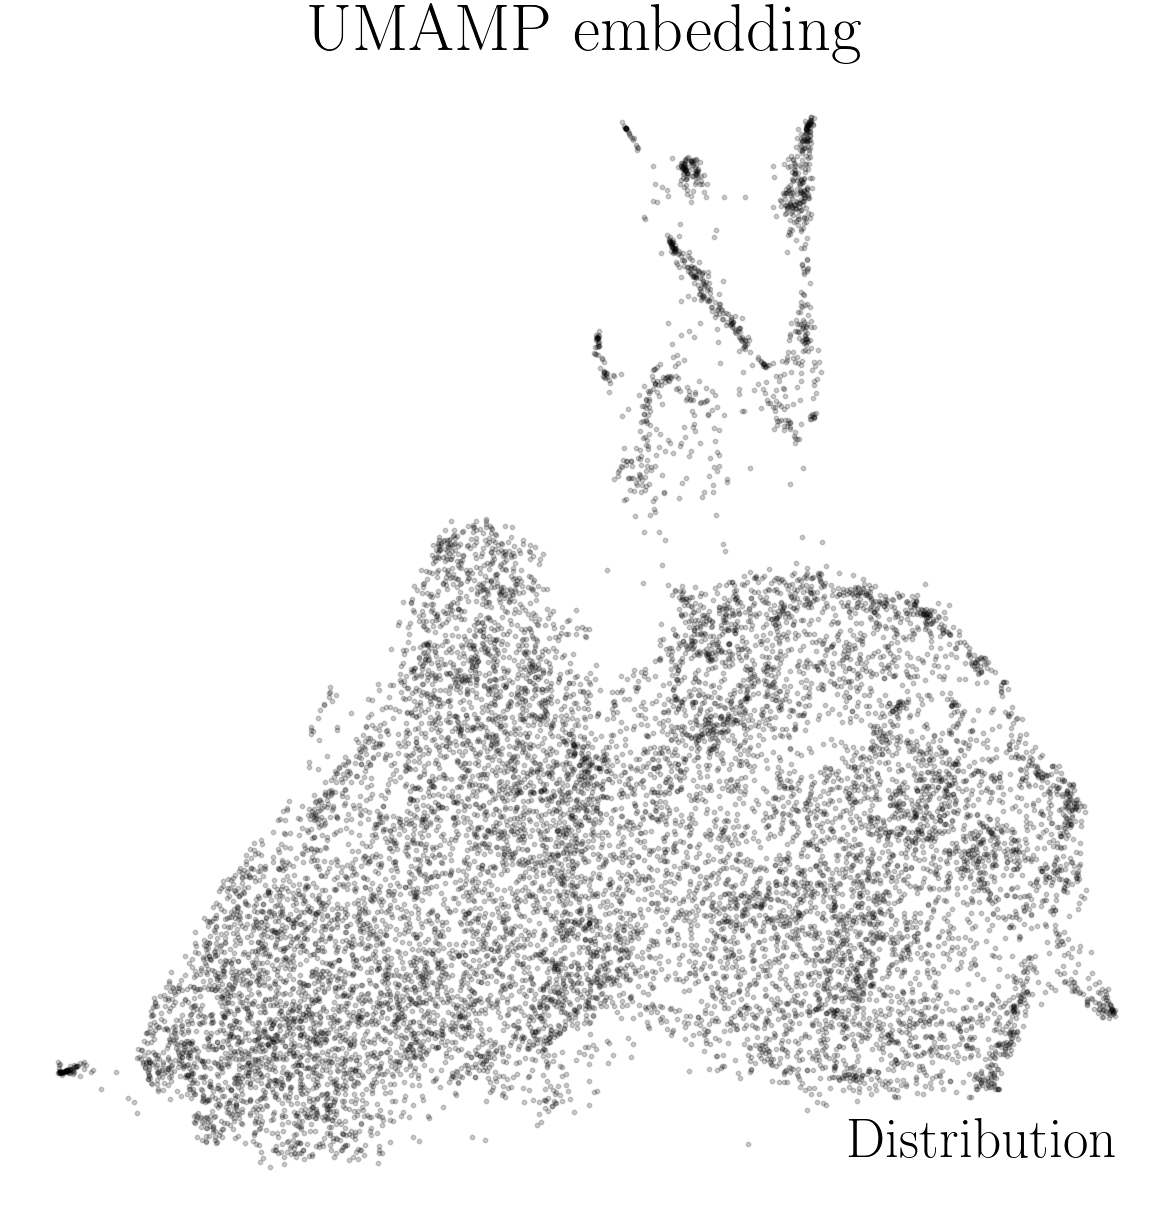

(89.62, 0.28)
[6 6 7 ... 0 0 6]
[0 2 1 ... 0 1 0]
2
pre Clustering accuracy 0.35405405405405405
2
pre Clustering accuracy 0.3383084577114428
2
pre Clustering accuracy 0.34022824536376606
2
pre Clustering accuracy 0.34728506787330315
0
pre Clustering accuracy 0.34475806451612906
0
pre Clustering accuracy 0.34421364985163205
0
pre Clustering accuracy 0.3734015345268542
1
pre Clustering accuracy 0.410828025477707
1
pre Clustering accuracy 0.346483704974271
2
pre Clustering accuracy 0.3559670781893004
Clustering accuracy 0.3499658236500342
Variance to keep :  0.41849420837825113  number of components :  2
48.296833315348536
0.4509249373589025
Computing background and RR distributions: will be slower
Background factor 1
Number of valid bins:  99
Repley's K:  (2.1195806899039384, 0.00026645148220523973)
Variance to keep :  0.4212159532673878  number of components :  2
49.00654260673355
0.4386816473609476
Computing background and RR distributions: will be slower
Background factor 1
Number of 

In [63]:
import torchvision as tv
weights = tv.models.ConvNeXt_Base_Weights.IMAGENET1K_V1

imnet_convnext_base = tv.models.convnext_base(weights = weights)

imnet_rep, imnet_label, imnet_ids = Custom.get_representations(model  = imnet_convnext_base,
                           loader = train,
                           encoder = True,
                           labeled = False)

imnet_rep_c, imnet_label_c, imnet_ids_c = Custom.get_representations(model  = imnet_convnext_base,
                           loader = class_,
                           encoder = True,
                           labeled = True)

umap_  =viz.umap(imnet_rep)

imnet_knn = test.KNN_accuracy(imnet_rep_c, imnet_label_c)
print(imnet_knn)
c_accuracy = test.clustering_accuracy((imnet_rep,imnet_ids),(imnet_label_c,imnet_ids_c))
imnet_tpcf = AstroMLmod.TPCF_score(imnet_rep)
print(imnet_tpcf)
imnet_id = AstroMLmod.id_score(imnet_rep)
print(imnet_id)

## Clustering accuracy

In [ ]:
sum([a in imnet_ids for a in imnet_ids_c])

In [49]:
importlib.reload(test)
c_accuracy = test.clustering_accuracy((zoobot_rep,zoobot_ids),(zoobot_label_c,zoobot_ids_c),n_clusters = 3)

[2 1 1 ... 2 0 1]
[0 1 2 ... 2 0 0]
0
pre Clustering accuracy 0.35009671179883944
1
pre Clustering accuracy 0.3406520292747838
2
pre Clustering accuracy 0.3419144307469181
Clustering accuracy 0.34313055365686945


Plotting


<Figure size 1050x787.5 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

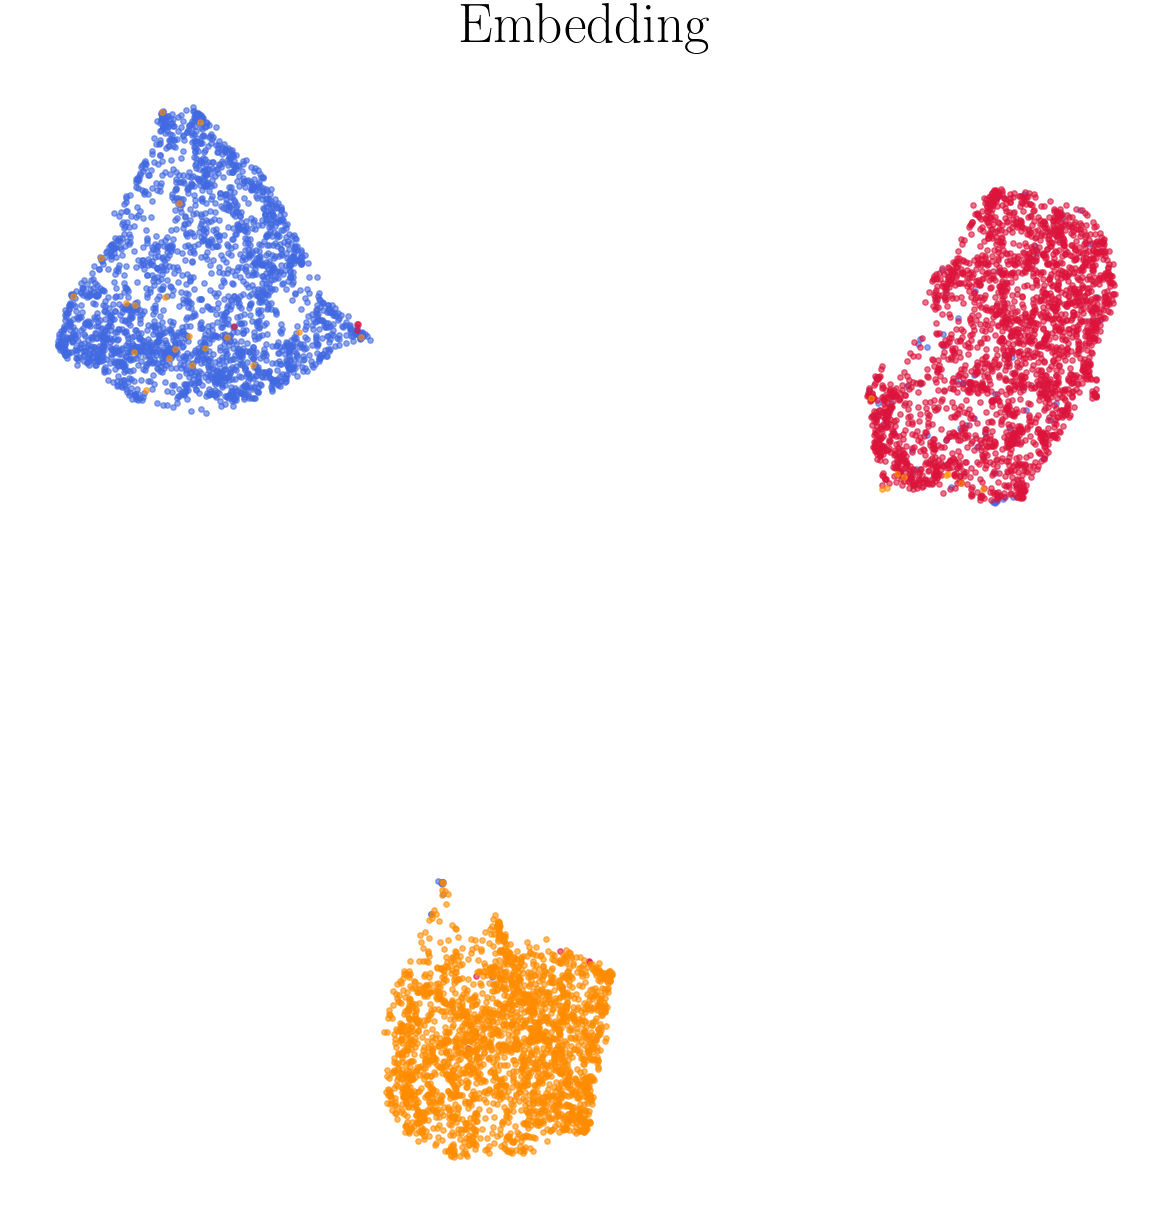

In [69]:
#pred = test.kmeans(imnet_rep, n_clusters = 3)
#umap_c  =viz.umap(zoobot_rep_c)

viz.shade(umap_cs,zoobot_label_c, numof_class=3)

In [126]:
((imnet_rep,imnet_ids),(imnet_label_c,imnet_ids_c))
t_pred = [0]*len(zoobot_rep)

#t_pred_mod = [imnet_label_c[imnet_ids.index(source_id)] for source_id in imnet_ids_c]
idds = []
for i in range(len(t_pred)):
    if zoobot_ids[i] in zoobot_ids_c:
        source_id = zoobot_ids[i]
        t_pred[i] = zoobot_label_c[zoobot_ids_c.index(source_id)] +1
        idds.append(source_id)

In [ ]:
#umap_css  =viz.umap(zoobot_rep)

viz.shade(umap_css,t_pred, numof_class=4, alpha = 0.3,legendd = True)

Plotting


<Figure size 1050x787.5 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

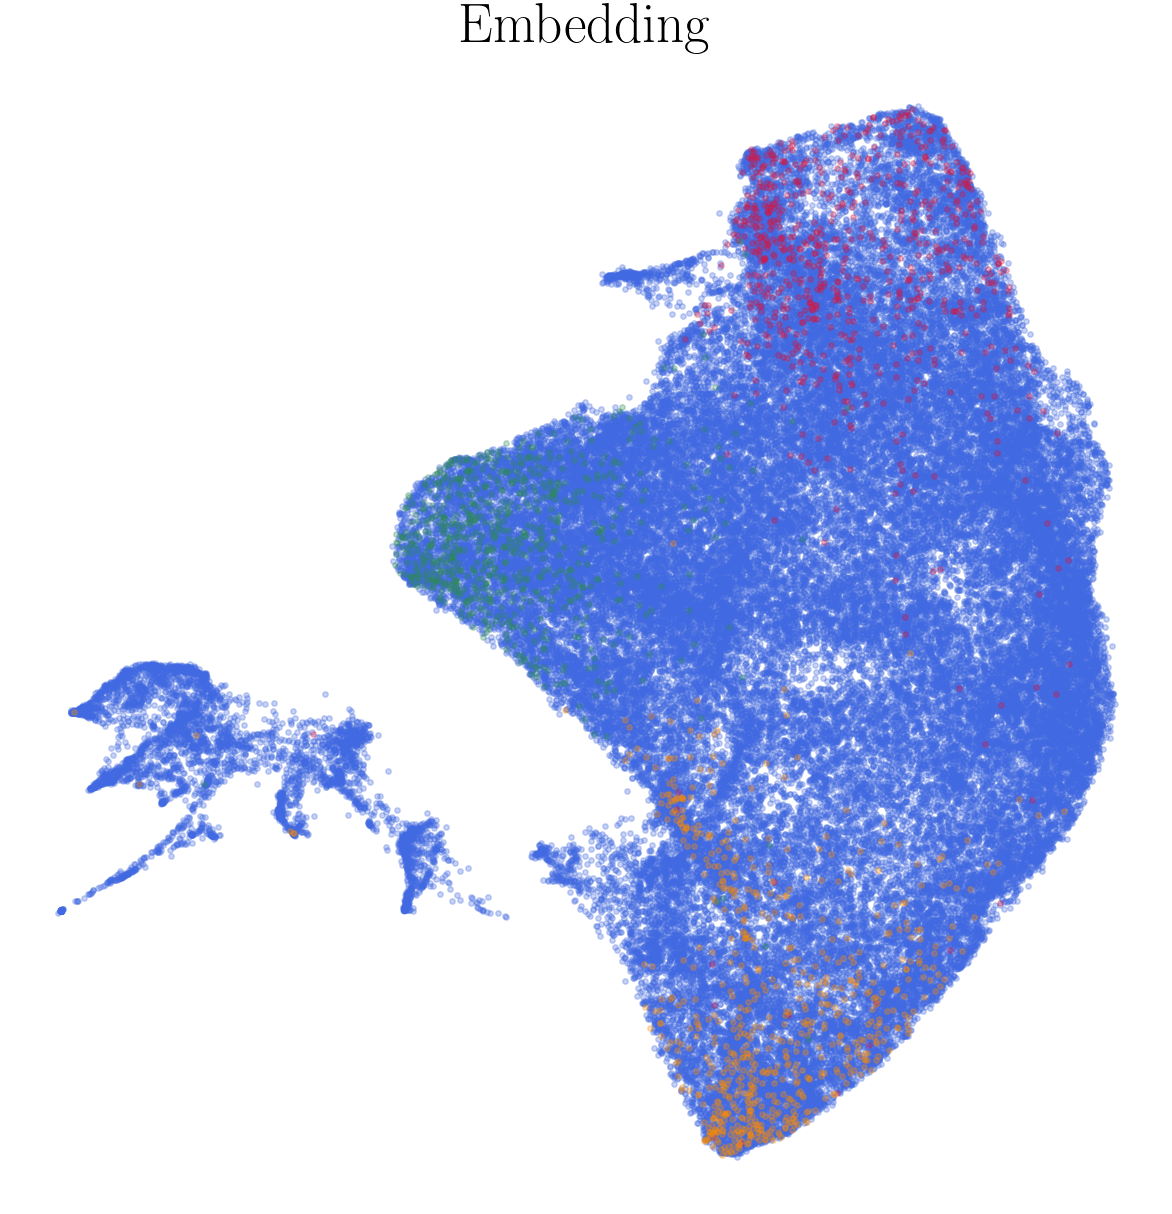

In [134]:
importlib.reload(test)
c_accuracy = test.clustering_accuracy((zoobot_rep,zoobot_ids),(zoobot_label_c,zoobot_ids_c))

[4 4 3 ... 6 8 6]
[2 2 1 ... 1 0 1]
2
pre Clustering accuracy 0.981651376146789
2
pre Clustering accuracy 0.5
0
pre Clustering accuracy 0.9767441860465116
1
pre Clustering accuracy 0.5572519083969466
2
pre Clustering accuracy 1.0
0
pre Clustering accuracy 0.9730458221024259
1
pre Clustering accuracy 0.9789303079416531
1
pre Clustering accuracy 0.5833333333333334
0
pre Clustering accuracy 0.995
0
pre Clustering accuracy 0.3333333333333333
Clustering accuracy 0.950374531835206


In [ ]:
s1 = zoobot_ids[2]
s2 = zoobot_ids[4]
zoobot_label_c[zoobot_ids_c.index(s1)],zoobot_label_c[zoobot_ids_c.index(s2)]

In [132]:
1 in set([1,2,3]) & set([123,321,1])

True